In [2]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

model = joblib.load("C:\\xampp\\htdocs\\ai-drug-price\\models\\medicine_price_model.pkl")

# Load the dataset
df = pd.read_csv("C:\\xampp\\htdocs\\ai-drug-price\\data\\cleaned_data_set\\cleaned.csv")


features = [
    "Generic Name",
    "Strength",
    "Pack Size",
    "Name of the Manufacturer",
    "Dosage Description",
    "Use For"
]

X = df[features]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

y_test_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)


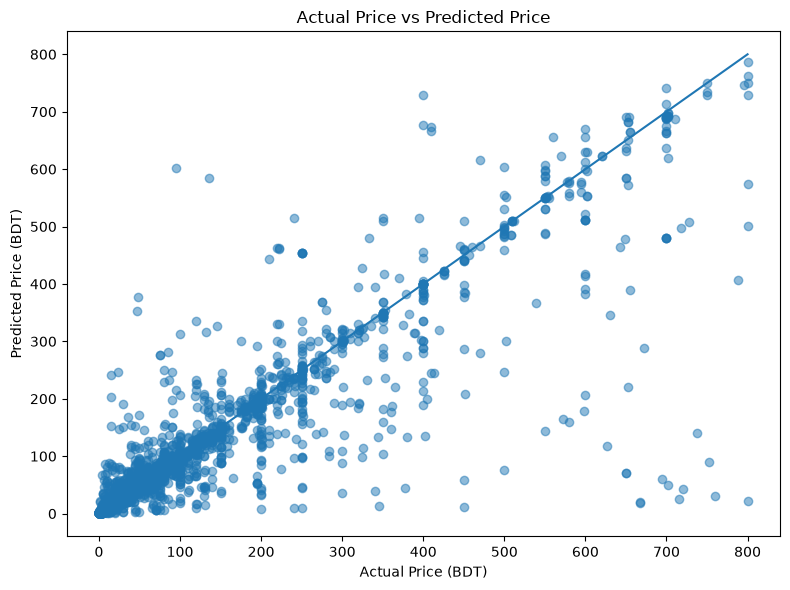

In [4]:
import matplotlib.pyplot as plt

# Actual Price vs Predicted Price
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price (BDT)")
plt.ylabel("Predicted Price (BDT)")
plt.title("Actual Price vs Predicted Price")

plt.tight_layout()
plt.show()